# documentation.quantum_gnns

Here we present the documentation for the modules in the `quantum_gnns` subdirectory of the `qGNNs` project.

```
qGNNs
    |
    |_ quantum_gnns
        |
        |_ qgtheta.py
    |
    .
    .
    .  
```

In [1]:
import os
os.chdir('..')

In [2]:
from quantum_gnns.qgtheta import *

The pipeline for this module is similar to the classical case (see the final part of this notebook).

## qgtheta

This module implements quantum graph neural network layers compatible with the `GraphInput` datastructure and classical Kipf-Welling layers.

### Classes

There are different classes.

#### BaseQuantumGraphFilter

The `BaseQuantumGraphFilter` class is the abstract base class defining the interface for quantum propagation of messages across the problem instance. This class should not be used in isolation.

**Arguments**
- `None`

**Methods**
- `forward`: Takes a `GraphInput` object and returns the features (shape `(N,F)`).

A conceptual example of this interface is described in the following snippet.
```
# Not directly instantiable
class DummyFilter(BaseQuantumGraphFilter):
    def forward(self, graph_input, features):
        return features
```

#### ExponentialQuantumGraphFilter

This class implements the quantum spectral filter $X\to e^{-i\alpha \tilde{L}} X$ where $\tilde{L}=I-$`graph_input.kipf_welling_adjacency()` (up to a global factor $\frac{2}{\lambda_{\max}}$ that normalizes, via the maximum eigenvalue of the adjacency matrix $\lambda_{\max}$, the spectrum of the adjusted Laplacian $\tilde{L}$). 

**Arguments** 
- `alpha`: the parameter $\alpha$ describing the parameter of the unitary evolution.
- `rescale_laplacian`: Boolean. If True uses $\tilde{L}$ instead of $L$ (normalizes the spectrum in $[-1,1]$). 

In [3]:
import networkx as nx
from utils.graphs import build_graph_input

graph_input = build_graph_input(nx.path_graph(4),[[1.0, 0.0],[0.5, 0.2],[0.0, 1.0],[0.2, 0.5]],)
q_filter = ExponentialQuantumGraphFilter(alpha=0.5)
X = graph_input.node_signals
X_q = q_filter.forward(graph_input, X)
X_classical = graph_input.kipf_welling_adjacency() @ X
print("Classical:\n", X_classical)
print("Quantum:\n", X_q)

Classical:
 [[0.70412415 0.08164966]
 [0.57491496 0.4       ]
 [0.24831632 0.60412415]
 [0.1        0.65824829]]
Quantum:
 [[ 0.93729855 -0.04553974]
 [ 0.43739389  0.17112388]
 [-0.03994219  0.90702668]
 [ 0.16643095  0.45364934]]


**Methods**

- `forward`: The forward pass of this class.

In [4]:
graph_input = build_graph_input(nx.path_graph(4), node_signals=[[1.0], [0.5], [0.2], [0.8]],)
ExponentialQuantumGraphFilter(alpha=0.5).forward(graph_input, graph_input.node_signals)

array([[0.92858341],
       [0.41328824],
       [0.13687862],
       [0.72962149]])

- internal functions such as 
    - `_build_laplacian`: builds the laplacian matrix
    - `_rescale_hermitian`: rescales the spectrum in $[-1,1]$
    - `_build_unitary`: builds $e^{-i\alpha L}$
    - ...

These functions are implicitly used in the forward method above and are quite technical. For further details see the comments in the associated source code.

### QuantumGraphLayer

The class `QuantumGraphLayer` is the quantum equivalent of the classical class `KipfWellingLayer`. It applies `H_out = activation(Q_G(H_in) @ W + b)`. 

**Arguments**
- `in_features`: Input feature dimension.
- `out_features`: Output feature dimension.
- `quantum_filter`: Quantum propagation block. If None, a default `ExponentialQuantumGraphFilter` is used.
- `activation`: Optional activation function.
- `use_bias`: Whether to use an additive bias term.
- `random_state`: Seed for deterministic weight initialization.

In [5]:
QuantumGraphLayer(in_features=2, out_features=2, activation=np.tanh,)

**Methods**

- `forward`: The forward pass of this class. It resolve features, applies the quantum filter, the linear map, the bias and the activation.

In [6]:
graph_input = build_graph_input(nx.path_graph(4), node_signals=[[1.0, 0.0], [0.5, 0.2], [0.0, 1.0], [0.2, 0.5]],)
layer = QuantumGraphLayer(in_features=2,out_features=2,activation=np.tanh,)
layer.forward(graph_input)

array([[-0.00120183, -0.01181793],
       [ 0.00924241, -0.00251833],
       [ 0.03969416,  0.00876256],
       [ 0.02170531,  0.00239831]])

#### SingleLayerQuantumGraphNetwork

The class `SingleLayerQuantumGraphNetwork` provides a minimal single-layer quantum graph neural network based on the `QuantumGraphLayer`. 

**Arguments**
- Same arguments as the `QuantumGraphLayer`

**Methods**
- Same arguments as the `QuantumGraphLayer` plus `__init__`

#### TwoLayerQuantumGraphNetwork
The class `TwoLayerQuantumGraphNetwork` is the quantum equivalent of the classical `two_layer_kipf_welling`. Since the arguments and methods are similar (essentially the same as the `SingleLayerQuantumGraphNetwork` class) we show below a complete example on how to run a general pipeline based on all these classes.

In [7]:
from classical_gnns.shallow_kipf_welling_gnn import *

# Topology and signals
G = nx.path_graph(5)
edge_signals = {
    (0, 1): [0.2],
    (1, 2): [0.5],
    (2, 3): [1.0],
    (3, 4): [0.7],
}
node_signals = [
    [1.0, 0.0],
    [0.5, 0.2],
    [0.0, 1.0],
    [0.2, 0.5],
    [1.0, 1.0],
]

# Build the problem instance
# Note: We use the same classical weights also inside the quantum model, so that the following comparison focuses on the propagation step.
graph_input = build_graph_input(G, node_signals=node_signals, edge_signals=edge_signals,)
A_hat = graph_input.kipf_welling_adjacency()
W1 = build_random_weight( in_features=2, out_features=3, seed=1, scale=0.5,)
W2 = build_random_weight( in_features=3, out_features=1, seed=2, scale=0.5,)
#print("Node order:", graph_input.node_order)
#print("Node signals:\n", graph_input.node_signals)
#print("Edge signals:", graph_input.edge_signals)
#print("Kipf-Welling normalized adjacency:\n", A_hat)
#print("W1:\n", W1)
#print("W2:\n", W2)

# Classical two-layer GNN
classical_layer1 = KipfWellingLayer(weight=W1,activation=relu,)
classical_layer2 = KipfWellingLayer(weight=W2,activation=identity,)
H1_classical = classical_layer1.forward(graph_input)
H2_classical = classical_layer2.forward(graph_input, features=H1_classical)
#print("Classical hidden representation H1:\n", H1_classical)
#print("H1_classical shape:", H1_classical.shape)
#print("Classical final representation H2:\n", H2_classical)
#print("H2_classical shape:", H2_classical.shape)

# Quantum two-layer GNN
# Note. We use the same filter in both layers for simplicity.
quantum_filter_1 = ExponentialQuantumGraphFilter(alpha=0.5,rescale_laplacian=True,)
quantum_filter_2 = ExponentialQuantumGraphFilter(alpha=0.5,rescale_laplacian=True,)
quantum_model = TwoLayerQuantumGraphNetwork(in_features=2,hidden_features=3,out_features=1,
                                            first_filter=quantum_filter_1,second_filter=quantum_filter_2,
                                            hidden_activation=relu,output_activation=identity,random_state=0,)
# Overwrite internally initialized weights so the comparison is fair.
quantum_model.layer1.weight = W1.copy()
quantum_model.layer2.weight = W2.copy()
quantum_model.layer1.bias = None
quantum_model.layer2.bias = None
H1_quantum = quantum_model.layer1.forward(graph_input)
H2_quantum = quantum_model.layer2.forward(graph_input, features=H1_quantum)
#print("Quantum hidden representation H1:\n", H1_quantum)
#print("H1_quantum shape:", H1_quantum.shape)
#print("Quantum final representation H2:\n", H2_quantum)
#print("H2_quantum shape:", H2_quantum.shape)

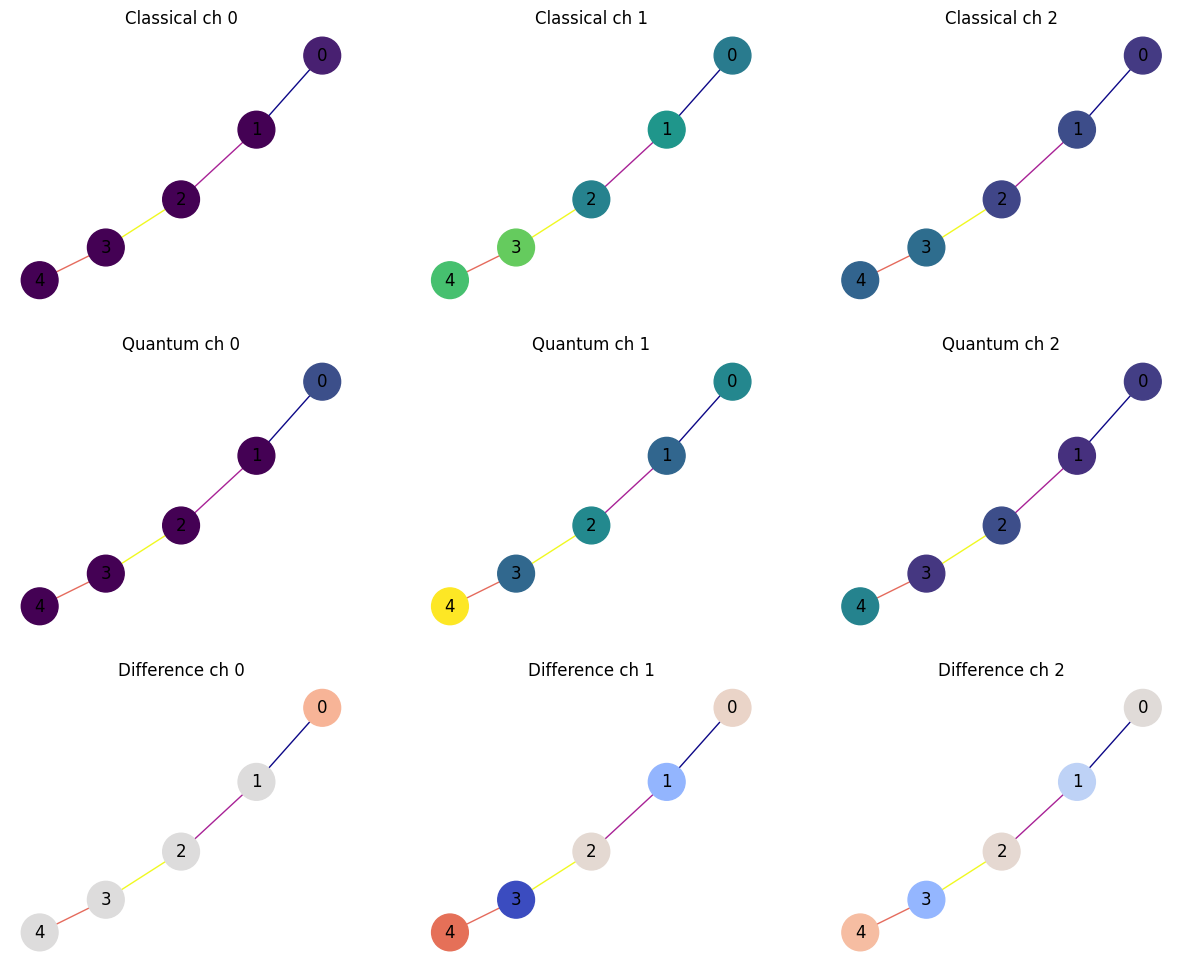

In [8]:
# Visualization and comparison
import matplotlib.pyplot as plt
#import matplotlib as mpl

pos = nx.spring_layout(G, seed=42)
#X = graph_input.node_signals
input_channel = graph_input.node_signals[:, 0]
hidden_channel_classical = H1_classical[:, 0]
output_channel_classical = H2_classical[:, 0]
hidden_channel_quantum = H1_quantum[:, 0]
output_channel_quantum = H2_quantum[:, 0]
edge_values = []
for u, v in G.edges():
    key = (u, v) if (u, v) in graph_input.edge_signals else (v, u)
    edge_values.append(graph_input.edge_signals[key][0])
num_hidden_channels = H1_classical.shape[1]
# Global scales for consistency across all channels
all_hidden_vals = np.concatenate([H1_classical.reshape(-1),H1_quantum.reshape(-1),])
vmin_hidden, vmax_hidden = all_hidden_vals.min(), all_hidden_vals.max()
all_diff_vals = (H1_quantum - H1_classical).reshape(-1)
dmax_global = np.max(np.abs(all_diff_vals))
fig, axes = plt.subplots(3, num_hidden_channels, figsize=(5 * num_hidden_channels, 12))
# Handle the special case num_hidden_channels == 1
if num_hidden_channels == 1:
    axes = np.array(axes).reshape(3, 1)
for j in range(num_hidden_channels):
    hidden_classical = H1_classical[:, j]
    hidden_quantum = H1_quantum[:, j]
    diff = hidden_quantum - hidden_classical
    # Classical
    nx.draw(G,pos,with_labels=True,node_color=hidden_classical,edge_color=edge_values,
            cmap="viridis",edge_cmap=plt.cm.plasma,vmin=vmin_hidden,vmax=vmax_hidden,node_size=700,ax=axes[0, j],)
    axes[0, j].set_title(f"Classical ch {j}")
    # Quantum
    nx.draw(G,pos,with_labels=True,node_color=hidden_quantum,edge_color=edge_values,
            cmap="viridis",edge_cmap=plt.cm.plasma,vmin=vmin_hidden,vmax=vmax_hidden,node_size=700,ax=axes[1, j],)
    axes[1, j].set_title(f"Quantum ch {j}")
    # Difference
    nx.draw(G,pos,with_labels=True,node_color=diff,edge_color=edge_values,
            cmap="coolwarm",edge_cmap=plt.cm.plasma,vmin=-dmax_global,vmax=dmax_global,node_size=700,ax=axes[2, j],)
    axes[2, j].set_title(f"Difference ch {j}")
plt.show()